In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
name = "2BPW_analysis"  # Replace with your desired name

rmsd_file = f"rmsd_{name}.out"
rmsf_file = f"rmsf_bb_{name}.dat"
ss_file = f"summary_ss_{name}.dat"
PP_file = f"PP_hbvtime_{name}.dat"
BB_file = f"BB_hbvtime_{name}.dat"
PW_file = f"PW_hbvtime_{name}.dat"
PL_file = f"PL_hbvtime_{name}.dat"
pca_file = f"pca_{name}.dat"

RMSD Backbone

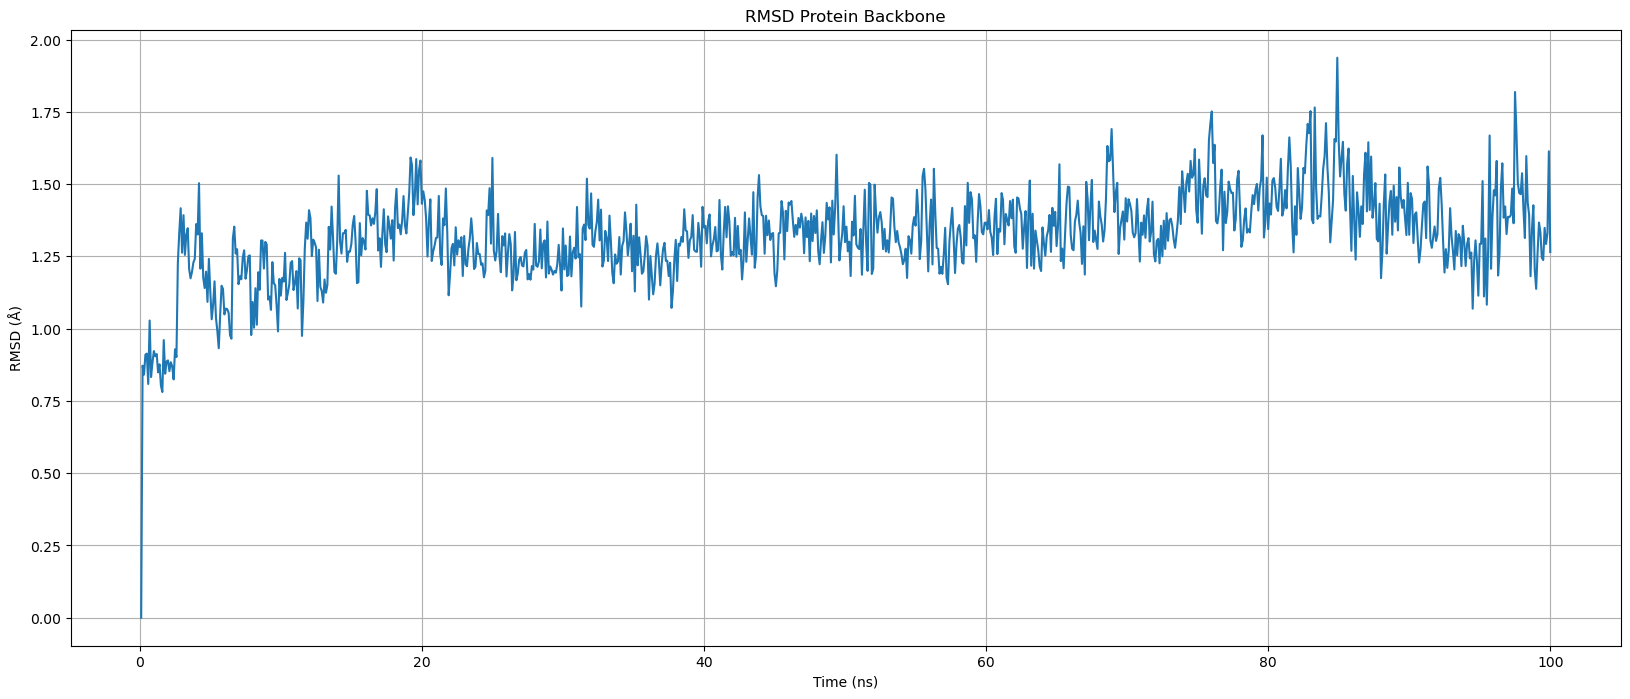

In [17]:
t, rmsd = np.loadtxt(rmsd_file, unpack=True)

plt.figure(figsize=(20,8))
plt.plot(t*0.1, rmsd)
plt.xlabel("Time (ns)")
plt.ylabel("RMSD (Å)")
plt.title("RMSD Protein Backbone")
plt.grid()
plt.show()

RMSF Backbone

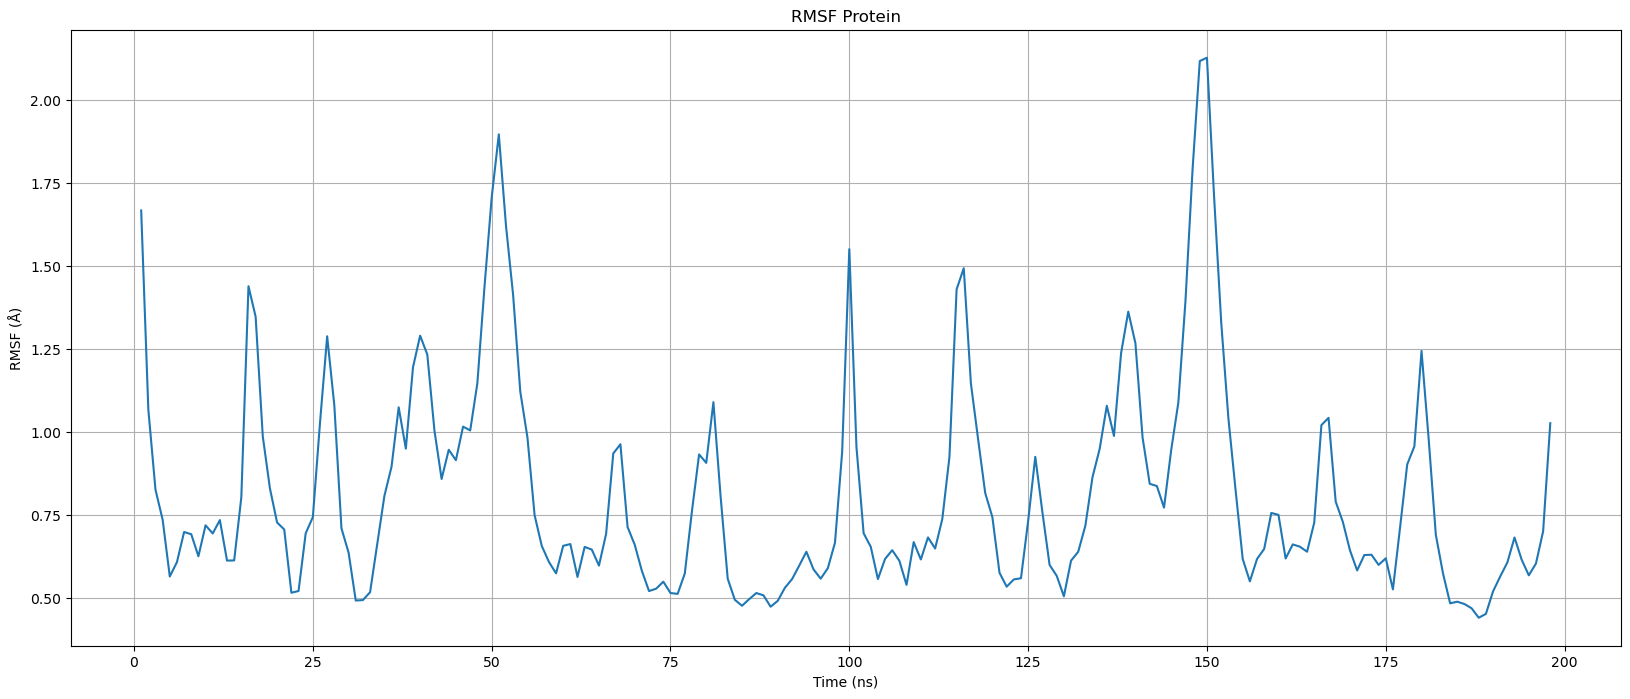

In [18]:
res, rmsf = np.loadtxt(rmsf_file, unpack=True)

plt.figure(figsize=(20,8))
plt.plot(res, rmsf)
plt.xlabel("Time (ns)")
plt.ylabel("RMSF (Å)")
plt.title("RMSF Protein")
plt.grid()
plt.show()

Secondary structure

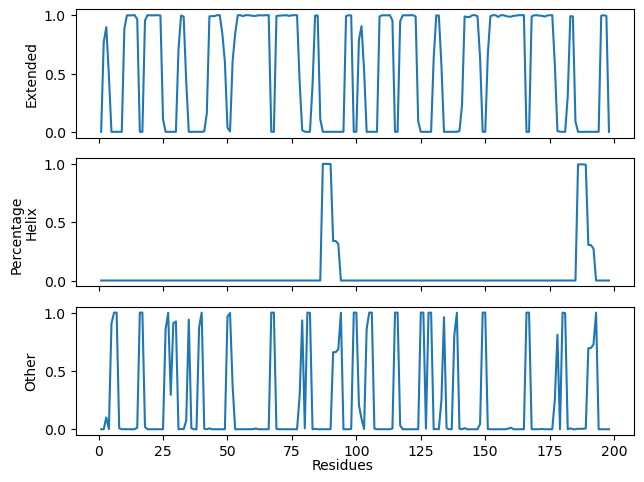

In [19]:
data =np.loadtxt(ss_file)
resid = data[:,0]
extended=data[:,1]
bridge=data[:,2]
three=data[:,3]
alpha=data[:,4]
pi=data[:,5]
turn=data[:,6]
bend=data[:,7]
helix = [0]*len(pi)
for i in range(len(pi)):
    b=three[i]
    c=alpha[i]
    d=pi[i]
    helix[i]=b+c+d
other=[0]*len(pi)
for i in range(len(pi)):
    e=bridge[i]
    f=turn[i]
    g=bend[i]
    other[i]=e+f+g
fig,ax=plt.subplots(3,1,sharex=True, sharey=True)
ax[0].plot(resid,extended,label='Extended')
ax[0].set_ylabel('Extended')
ax[1].plot(resid,helix,label='Helix')
ax[1].set_ylabel('Helix')
ax[2].plot(resid,other,label='Other')
ax[2].set_ylabel('Other')
fig.text(0.52,0.01,'Residues',ha='center')
fig.text(0.001,0.5,'Percentage',va='center',rotation='vertical')
#fig.ylabel('Percentage of Time')
plt.tight_layout()

Hydrogen bonds

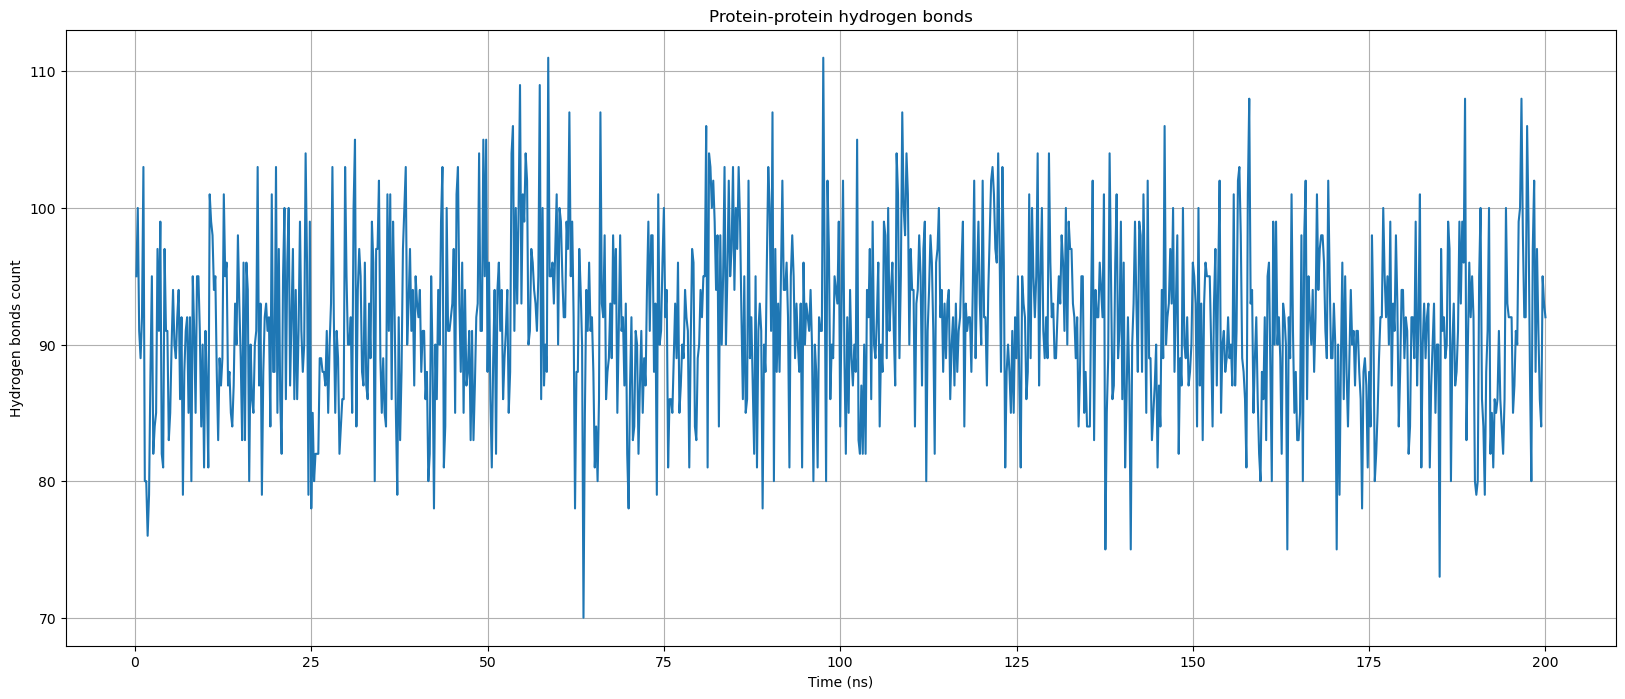

Average protein-protein hydrogen bonds: 91.44
Standard deviation of protein-protein hydrogen bonds: 6.34


In [20]:
t, hbond = np.loadtxt(PP_file, unpack=True)

plt.figure(figsize=(20,8))
plt.plot(t*0.2, hbond)
plt.xlabel("Time (ns)")
plt.ylabel("Hydrogen bonds count")
plt.title("Protein-protein hydrogen bonds")
plt.grid()
plt.show()

print (f"Average protein-protein hydrogen bonds: {np.mean(hbond):.2f}")
print (f"Standard deviation of protein-protein hydrogen bonds: {np.std(hbond):.2f}")

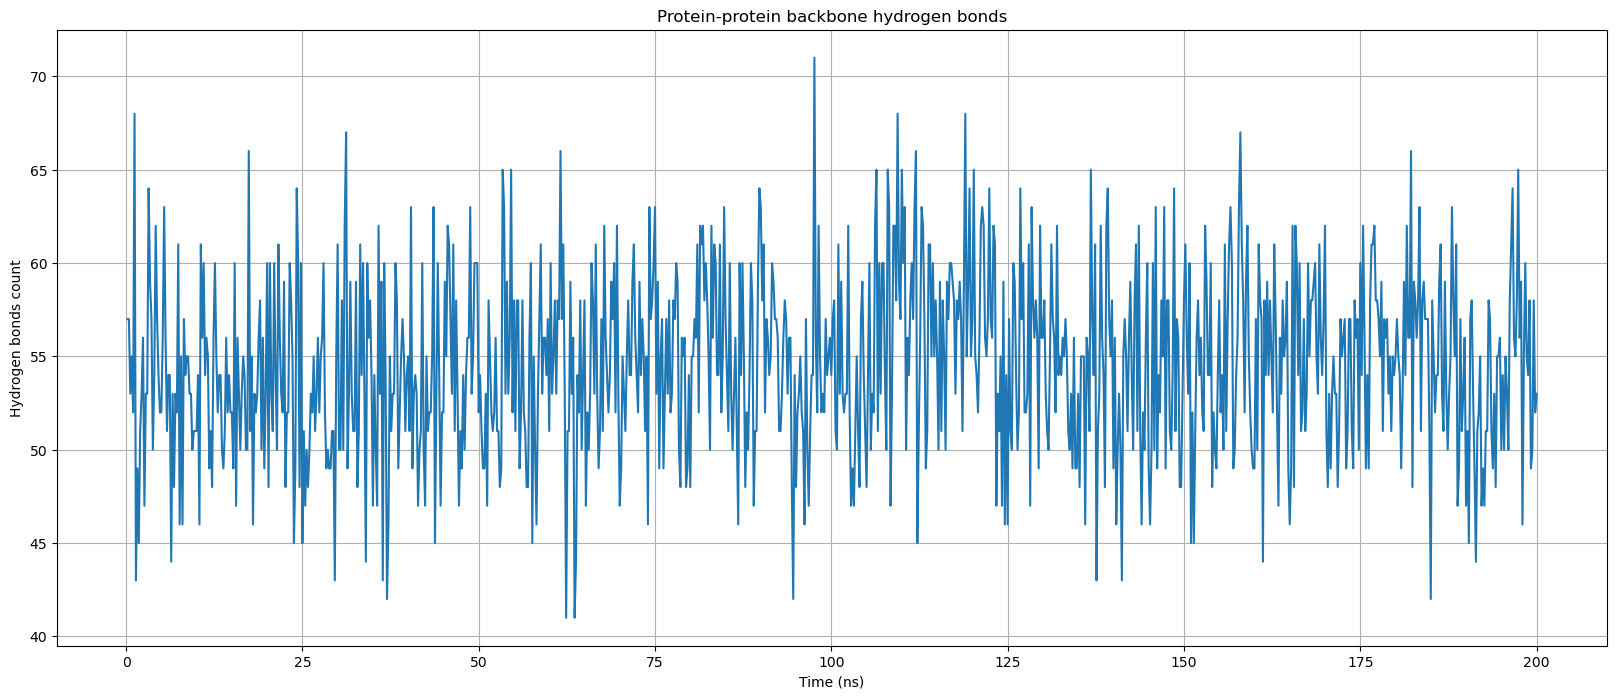

Average protein-protein backbone hydrogen bonds: 54.55
Standard deviation of protein-protein backbone hydrogen bonds: 4.78


In [21]:
t, hbond = np.loadtxt(BB_file, unpack=True)

plt.figure(figsize=(20,8))
plt.plot(t*0.2, hbond)
plt.xlabel("Time (ns)")
plt.ylabel("Hydrogen bonds count")
plt.title("Protein-protein backbone hydrogen bonds")
plt.grid()
plt.show()

print (f"Average protein-protein backbone hydrogen bonds: {np.mean(hbond):.2f}")
print (f"Standard deviation of protein-protein backbone hydrogen bonds: {np.std(hbond):.2f}")

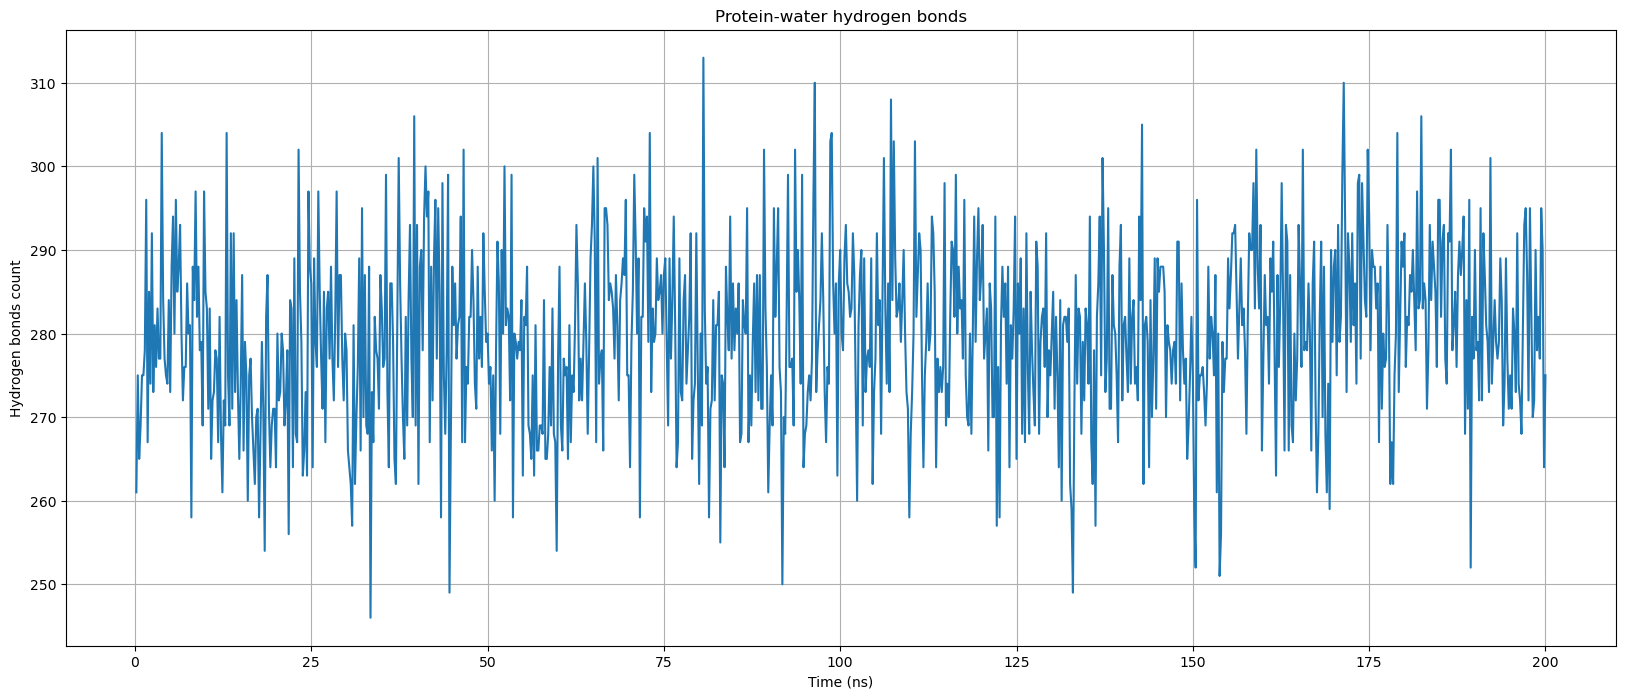

Average protein-water hydrogen bonds: 279.71
Standard deviation of protein-water hydrogen bonds: 10.44


In [22]:
t, hbond = np.loadtxt(PW_file, unpack=True)

plt.figure(figsize=(20,8))
plt.plot(t*0.2, hbond)
plt.xlabel("Time (ns)")
plt.ylabel("Hydrogen bonds count")
plt.title("Protein-water hydrogen bonds")
plt.grid()
plt.show()

print (f"Average protein-water hydrogen bonds: {np.mean(hbond):.2f}")
print (f"Standard deviation of protein-water hydrogen bonds: {np.std(hbond):.2f}")

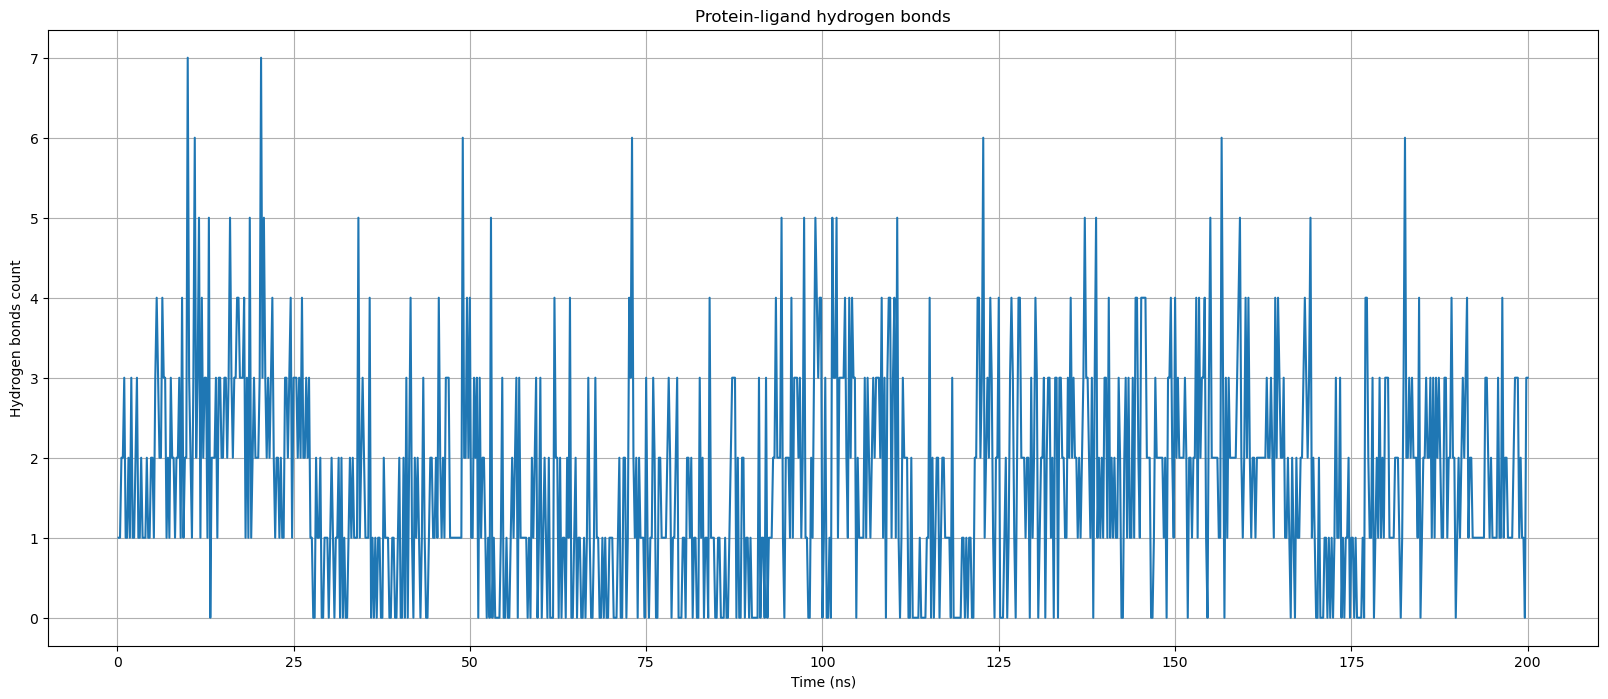

Average protein-ligand hydrogen bonds: 1.71
Standard deviation of protein-ligand hydrogen bonds: 1.30


In [23]:
t, hbond = np.loadtxt(PL_file, unpack=True)

plt.figure(figsize=(20,8))
plt.plot(t*0.2, hbond)
plt.xlabel("Time (ns)")
plt.ylabel("Hydrogen bonds count")
plt.title("Protein-ligand hydrogen bonds")
plt.grid()
plt.show()

print (f"Average protein-ligand hydrogen bonds: {np.mean(hbond):.2f}")
print (f"Standard deviation of protein-ligand hydrogen bonds: {np.std(hbond):.2f}")

PCA

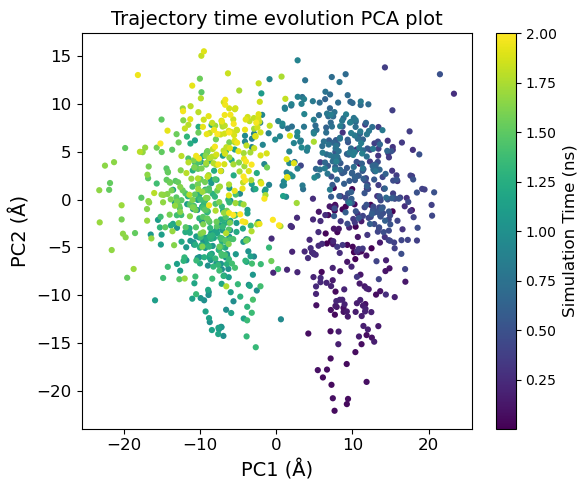

In [24]:
data = np.loadtxt(pca_file)
frame = data[:, 0]
pc1 = data[:, 1]
pc2 = data[:, 2]


# Normalize time for coloring
time = frame*0.002

plt.figure(figsize=(6,5))

sc = plt.scatter(pc1, pc2, c=time, cmap='viridis',
                 s=20, edgecolor='none')

cbar = plt.colorbar(sc)
cbar.set_label("Simulation Time (ns)", fontsize=12)

plt.xlabel("PC1 (Å)", fontsize=14)
plt.ylabel("PC2 (Å)", fontsize=14)
plt.title("Trajectory time evolution PCA plot", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

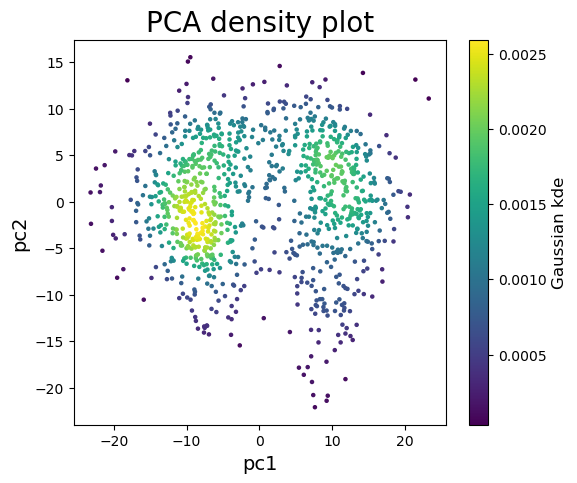

In [25]:
from scipy.stats import gaussian_kde

xy = np.vstack([pc1,pc2])
z = gaussian_kde(xy)(xy)

plt.figure(figsize=(6,5))
scc = plt.scatter(pc1,pc2, c=z, s=5)

cbar = plt.colorbar(scc)
cbar.set_label("Gaussian kde", fontsize=12)

plt.xlabel('pc1',fontsize=14)
plt.ylabel('pc2', fontsize=14)
plt.title("PCA density plot", fontsize=20)

plt.show()

Text(0.5, 1.0, 'PC1 time evolution')

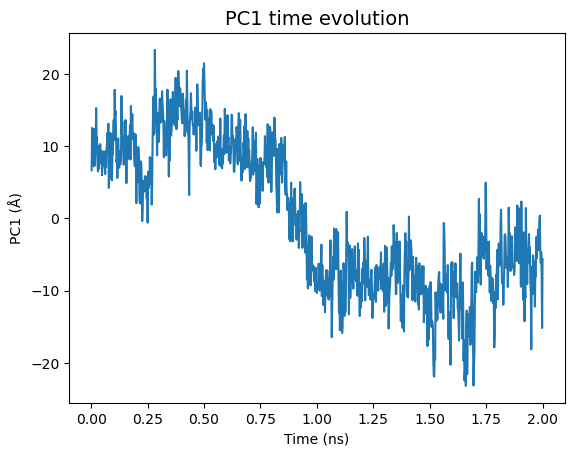

In [26]:
plt.plot(time, pc1);
plt.xlabel("Time (ns)")
plt.ylabel("PC1 (Å)")
plt.title("PC1 time evolution", fontsize=14)